# Karl Negrillo: C22386123
# Decision Making using Court Line Detection and Ball Detection


In [39]:
# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import easygui

Selected: C:\Users\negri\Documents\Year4\.Semester 1\Image Processing\Volleyball-Line-Detection\sample_images\Sample_Input_3.jpg


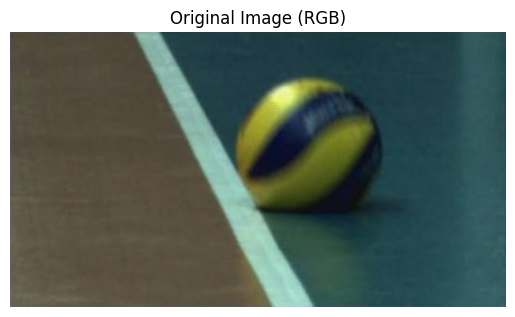

In [40]:
# Initial block for image loading and normalising, we should use this as the base 
# for both the line detection and ball detection so we have a consistent image variables.
# Let the user pick an image
input_path = easygui.fileopenbox("Select volleyball court image:")
print("Selected:", input_path)

image_bgr = cv2.imread(input_path)
if image_bgr is None:
    raise ValueError("Could not read image, check the path.")

# resize to a consistent width
target_width = 800
h, w = image_bgr.shape[:2]
scale = target_width / w
image_bgr = cv2.resize(image_bgr, (target_width, int(h * scale)))

# Convert to RGB for matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

### Pre-Processing, Hough Lines, Canny Edges, Court Line Polygon ROI
Extracting the Court Lines

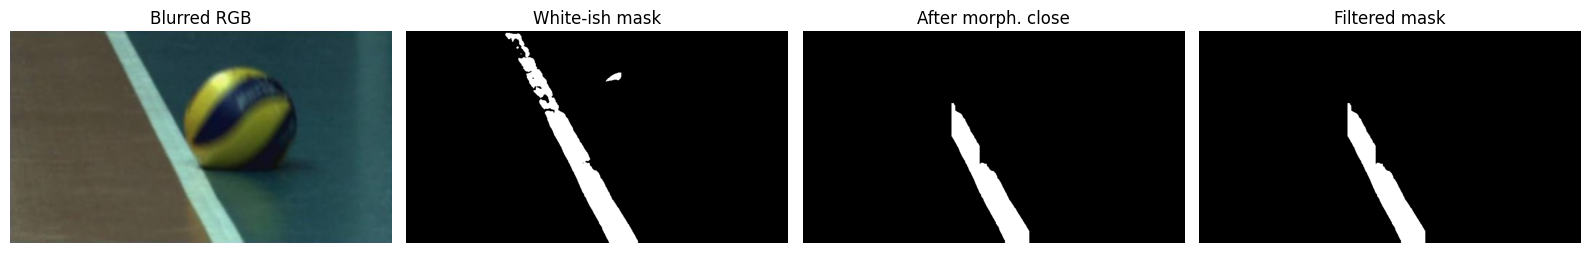

In [41]:
# PreProcessing, Color Mask and Connected Components for Line Detection
def PreProcess_ExtractLines(image_bgr, min_area=150, debug=False):

    # Light denoising
    blurred_bgr = cv2.GaussianBlur(image_bgr, (5, 5), 0)
    blurred_rgb = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2RGB)

    # Convert to HSV (for brightness / saturation masking)
    hsv = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # Threshold on brightness (V) and low saturation (S) to get whitish regions
    _, v_mask = cv2.threshold(V, 180, 255, cv2.THRESH_BINARY) # very bright
    _, s_mask = cv2.threshold(S, 100, 255, cv2.THRESH_BINARY_INV) # low saturation 

    white_mask = cv2.bitwise_and(v_mask, s_mask)

    # Morphology to clean up and join courtline fragments slightly more
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 50))
    opened = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel_open, iterations=1)

    vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 9))
    line_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, vert_kernel, iterations=1)

    # Connected components, keep only sufficiently large bright regions
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(line_mask)

    # min_area = 150 # remove tiny blobs
    filtered = np.zeros_like(line_mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            filtered[labels == i] = 255

    # Return everything you actually need
    return blurred_rgb, white_mask, line_mask, filtered

blurred_rgb, white_mask, line_mask, filtered = PreProcess_ExtractLines(image_bgr)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(blurred_rgb); axes[0].set_title("Blurred RGB"); axes[0].axis("off")
axes[1].imshow(white_mask, cmap="gray"); axes[1].set_title("White-ish mask"); axes[1].axis("off")
axes[2].imshow(line_mask, cmap="gray"); axes[2].set_title("After morph. close"); axes[2].axis("off")
axes[3].imshow(filtered, cmap="gray"); axes[3].set_title("Filtered mask"); axes[3].axis("off")
plt.tight_layout(); plt.show()


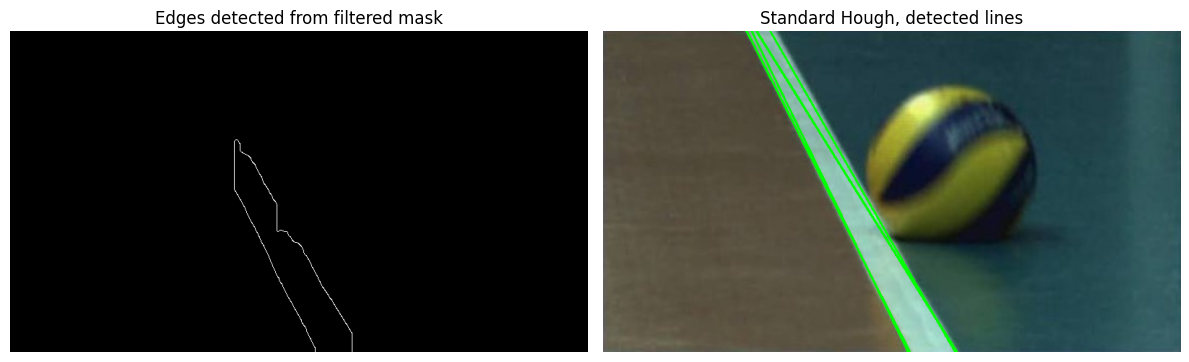

In [42]:
# Canny edges, Hough transforms (segments and infinite lines)
def detect_HoughLines(filtered, image_rgb):

    # Edges from filtered mask
    edges = cv2.Canny(filtered, 50, 150, apertureSize=3)

    # Standard Hough: This is what we use for the stripe ROI
    vis = image_rgb.copy()

    lines = cv2.HoughLines(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80 
    )

    if lines is not None:
        for i in range(len(lines)):
            rho, theta = lines[i][0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            # two far points for drawing
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))

            cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

        return edges, vis, lines
    
edges, vis, lines = detect_HoughLines(filtered, image_rgb)

# Show edges
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: edges
axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Edges detected from filtered mask")
axes[0].axis("off")

# Right: Hough lines
axes[1].imshow(vis)
axes[1].set_title("Standard Hough, detected lines")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Dominant theta (deg): 151.49998
Hough lines near dominant orientation for ROI: 4


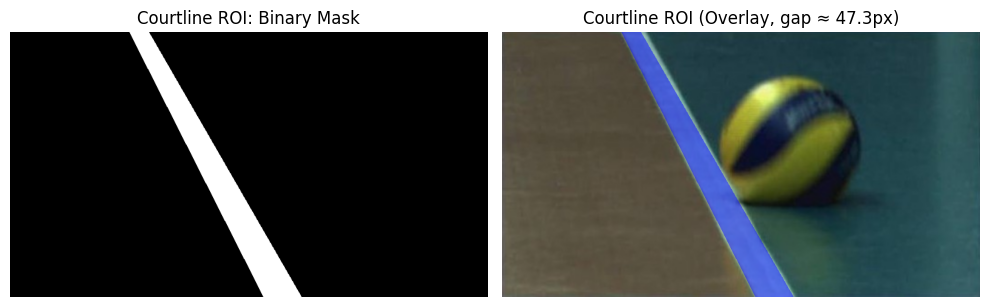

In [43]:
# Courtline polygon ROI (works for vertical & angled stripes)
# Outputs a binary mask of courtline and visual overlay that we can use
# for our decision method.
def compute_courtline_ROI(image_rgb, lines):
    h, w = image_rgb.shape[:2]

    def angle_diff(a, b):
        """Smallest difference between two angles in [0, pi]."""
        d = abs(a - b)
        return min(d, np.pi - d)

    def line_x_at_y(rho, theta, y):
        """Return x where line (rho, theta) crosses y, or None if invalid."""
        c = np.cos(theta)
        if abs(c) < 1e-3: # avoid division by zero if nearly horizontal
            return None
        return (rho - y * np.sin(theta)) / c
    
    # Estimate dominant line orientation from Hough lines
    dominant_theta = None
    if lines is not None:
        thetas = [l[0][1] for l in lines] # theta from each (rho, theta)
        if len(thetas) > 0:
            dominant_theta = np.median(thetas)
            print("Dominant theta (deg):", np.degrees(dominant_theta))
        else:
            print("No thetas from Hough lines.")
    else:
        print("No Hough lines found; cannot estimate dominant orientation.")
    
    # Collect candidate border lines near the dominant orientation
    border_lines = [] # list of (x_mid, rho, theta)
    if lines is not None and dominant_theta is not None:
        for i in range(len(lines)):
            rho, theta = lines[i][0]

            # keep only lines whose angle is close to the dominant stripe angle
            if angle_diff(theta, dominant_theta) > np.deg2rad(10):
                continue

            # must intersect top and bottom inside the image
            x_top = line_x_at_y(rho, theta, 0)
            x_bot = line_x_at_y(rho, theta, h - 1)
            if x_top is None or x_bot is None:
                continue
            if not (0 <= x_top < w and 0 <= x_bot < w):
                continue

            # x at vertical centre (y = h/2) for measuring the gap
            x_mid = line_x_at_y(rho, theta, h / 2.0)
            if x_mid is None or not (0 <= x_mid < w):
                continue

            border_lines.append((x_mid, rho, theta))
    print("Hough lines near dominant orientation for ROI:", len(border_lines))

    # Choose the pair with the largest sensible gap at centre (this is the full width of courtline)
    if len(border_lines) >= 2:
        max_rel_width = 0.15 # 15% of image width (upper bound)
        min_rel_width = 0.01 # 1% of width (lower bound)
        max_width_px = max_rel_width * w
        min_width_px = min_rel_width * w

        best_pair = None
        best_gap  = -1.0

        # try all pairs 
        for i in range(len(border_lines)):
            x1, rho1, theta1 = border_lines[i]
            for j in range(i + 1, len(border_lines)):
                x2, rho2, theta2 = border_lines[j]
                gap = abs(x2 - x1)

                if gap < min_width_px or gap > max_width_px:
                    continue

                if gap > best_gap:
                    best_gap  = gap
                    best_pair = (x1, rho1, theta1, x2, rho2, theta2)
        
        # Fallback, if nothing obeys the width constraint, use outermost pair
        if best_pair is None:
            border_lines.sort(key=lambda t: t[0])
            x1, rho1, theta1 = border_lines[0]
            x2, rho2, theta2 = border_lines[-1]
            best_gap = abs(x2 - x1)
            best_pair = (x1, rho1, theta1, x2, rho2, theta2)
            print("Fallback, using extreme pair without width constraint.")

        if best_pair is not None:
            xmid1, rho1, theta1, xmid2, rho2, theta2 = best_pair

            # Build polygon between these two lines using top & bottom intersections
            x1_top = line_x_at_y(rho1, theta1, 0)
            x1_bottom = line_x_at_y(rho1, theta1, h - 1)
            x2_top = line_x_at_y(rho2, theta2, 0)
            x2_bottom = line_x_at_y(rho2, theta2, h - 1)

            pts = np.array([
                [int(round(x1_top)), 0],
                [int(round(x2_top)), 0],
                [int(round(x2_bottom)), h - 1],
                [int(round(x1_bottom)), h - 1]
            ], dtype=np.int32)

            # final courtline mask (polygon ROI)
            line_roi_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(line_roi_mask, [pts], 255)

            # Overlay
            vis_roi = image_rgb.copy()
            overlay = vis_roi.copy()
            cv2.fillPoly(overlay, [pts], (0, 0, 255))
            vis_roi = cv2.addWeighted(overlay, 0.5, vis_roi, 0.5, 0)

            return line_roi_mask, vis_roi, best_gap
        
        else:
            print("No suitable pair of lines found for polygon ROI.")
            return None, None, None
    else:
        print("Not enough Hough lines / no dominant orientation to build polygon ROI.")
        return None, None, None

line_roi_mask, vis_roi, best_gap = compute_courtline_ROI(image_rgb, lines)

if line_roi_mask is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    axes[0].imshow(line_roi_mask, cmap="gray")
    axes[0].set_title("Courtline ROI: Binary Mask")
    axes[0].axis("off")

    axes[1].imshow(vis_roi)
    axes[1].set_title(f"Courtline ROI (Overlay, gap ≈ {best_gap:.1f}px)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



### Ball Detection

Extracting the Ball

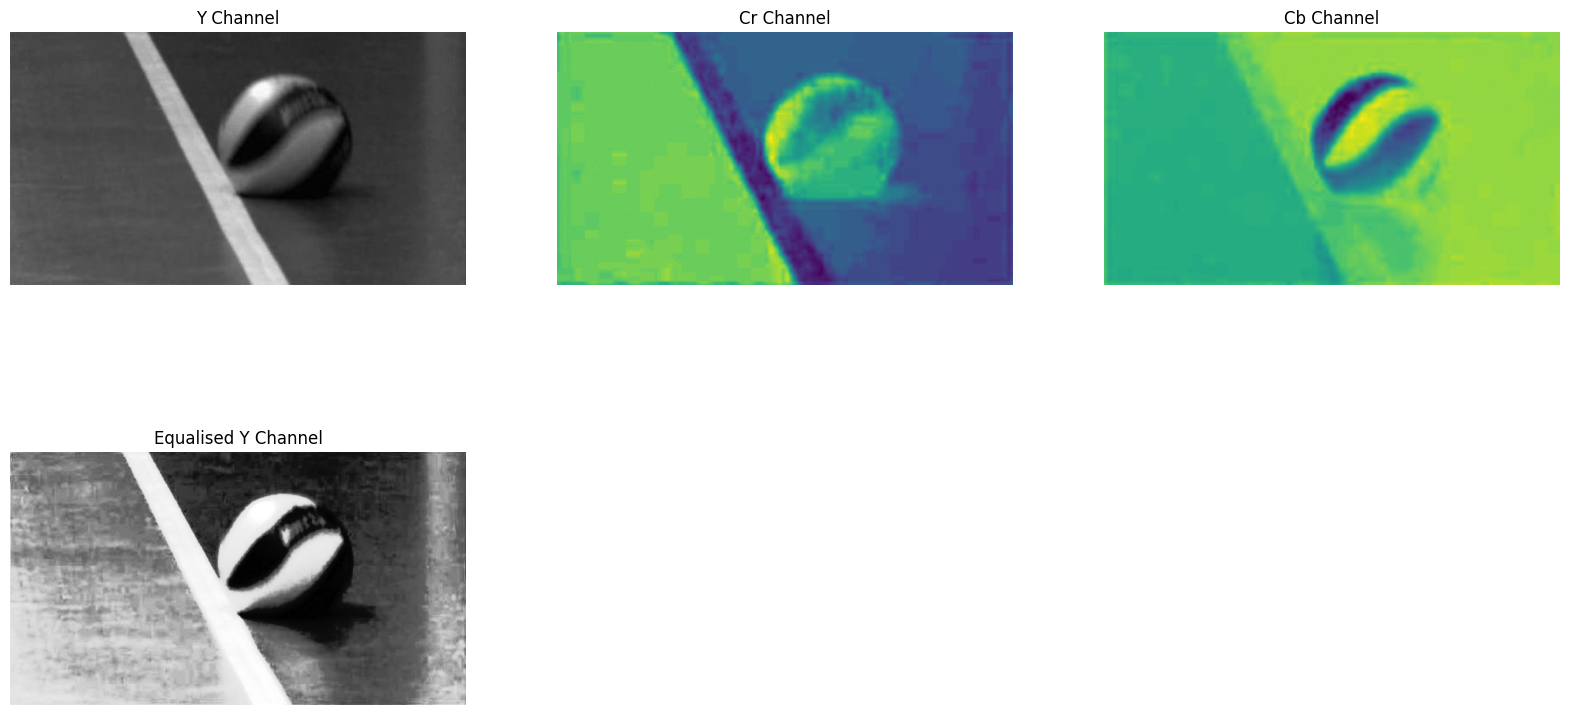

In [44]:
# Function to extract YCrCb channels and equalize the Y channel, displaying each step
def preprocess_channels(image_bgr):
    """Extract Y, Cr, Cb and equalised Y from the input image."""
    YCrCb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(YCrCb)
    equalised_y = cv2.equalizeHist(Y)
    YCrCb_eq = cv2.merge([equalised_y, Cr, Cb])

    plt.figure(figsize=(20,10))
    plt.subplot(2,3,1)
    plt.title('Y Channel')
    plt.imshow(Y, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2,3,2)
    plt.title('Cr Channel')
    plt.imshow(Cr)
    plt.axis('off')
    
    plt.subplot(2,3,3)
    plt.title('Cb Channel')
    plt.imshow(Cb)
    plt.axis('off')
    
    plt.subplot(2,3,4)
    plt.title('Equalised Y Channel')
    plt.imshow(equalised_y, cmap='gray')
    plt.axis('off')

    # plt.tight_layout()
    plt.show()
    return Y, Cr, Cb, equalised_y, YCrCb_eq

# Example usage:
Y, Cr, Cb, equalised_y, YCrCb_eq = preprocess_channels(image_bgr)

### Ball Detection

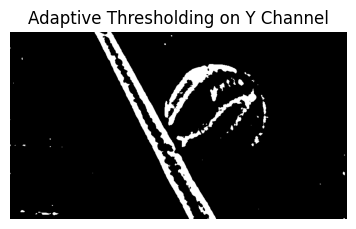

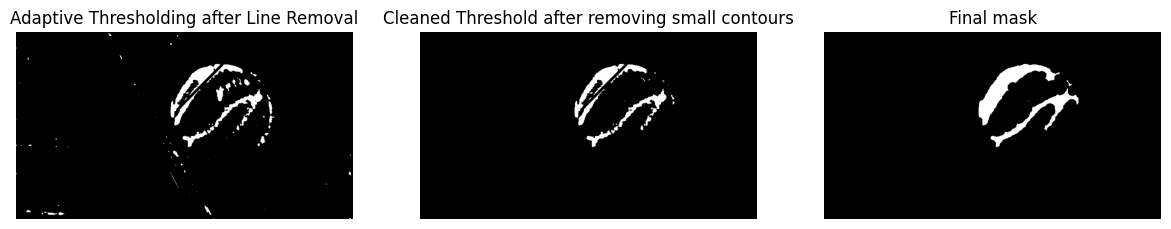

In [45]:
def create_ball_mask(image_bgr):
    image_bgr = cv2.GaussianBlur(image_bgr, (5, 5), 0)
    image_ycrcb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(image_ycrcb)

    # Adatptive thresholding on Y channel which filters out some lines and the ball
    adaptive_thresh = cv2.adaptiveThreshold(Y, maxValue=255, adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           thresholdType=cv2.THRESH_BINARY, blockSize=49, C=-5)
    # Displays the adaptive threshold result (can be removed if you want)
    plt.figure(figsize=(20,10))
    plt.subplot(1,4,1)
    plt.title('Adaptive Thresholding on Y Channel')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')

    ## -----This section removes court lines from the thresholded image---- ##
    
    # Detect the inner and outer edge of the court line using hough transform
    lines = cv2.HoughLinesP(adaptive_thresh, rho=1, theta=np.pi/180, threshold=200,
                            minLineLength=50, maxLineGap=10)

    # Remove detected lines from adaptive_thresh
    if lines is not None: 
        for line in lines:
            x1, y1, x2, y2 = line[0] # Extract line endpoints
            cv2.line(adaptive_thresh, pt1=(x1, y1), pt2=(x2, y2), color=(0), thickness=5)
    ## --------------------------------------------------------------- ##

    # Remove the noise by removing small contours
    contours, _ = cv2.findContours(adaptive_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    min_contour_area = 400
    cleaned_thresh = np.zeros_like(adaptive_thresh)
    for contour in contours:
        if cv2.contourArea(contour) >= min_contour_area:
            cv2.drawContours(cleaned_thresh, [contour], -1, color=255, thickness=-1)

    # Close gaps in the detected contours
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    closed_thresh = cv2.morphologyEx(cleaned_thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Dialate to further close gaps
    closed_thresh = cv2.dilate(closed_thresh, kernel, iterations=10)

    # Remove more small noise
    closed_thresh = cv2.morphologyEx(closed_thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Combine with original adaptive threshold to ensure only relevant areas are left
    cleaned_thresh = cv2.bitwise_and(closed_thresh, adaptive_thresh, mask=closed_thresh)

    # Close gaps in the final mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11,11))
    final_mask = cv2.morphologyEx(cleaned_thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Displays the results (can be removed if you want)
    plt.figure(figsize=(20,10))
    plt.subplot(1,4,2)
    plt.title('Adaptive Thresholding after Line Removal')
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4,3)
    plt.title('Cleaned Threshold after removing small contours')
    plt.imshow(cleaned_thresh, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4,4)
    plt.title('Final mask')
    plt.imshow(final_mask, cmap='gray')
    plt.axis('off')

    return final_mask

ball_mask = create_ball_mask(image_bgr)

This function detects the ball using the mask created, finds contours in the mask, combines the two largest contours into one and creates a boundary box to crop the close up area of the ball. Further processing is then done in order to accurately detect the contact point of the ball and the floor. 

**Input: RGB image, binary ball mask** \
**Output: RGB image with detected ball outlined, Coordinates of the ball-floor contact line**

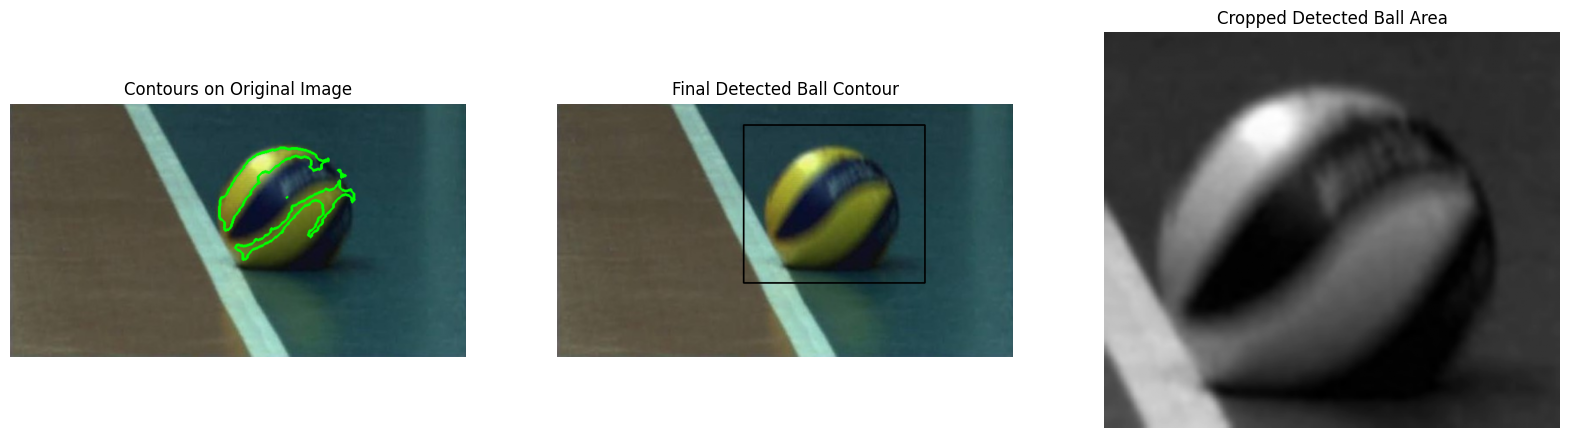

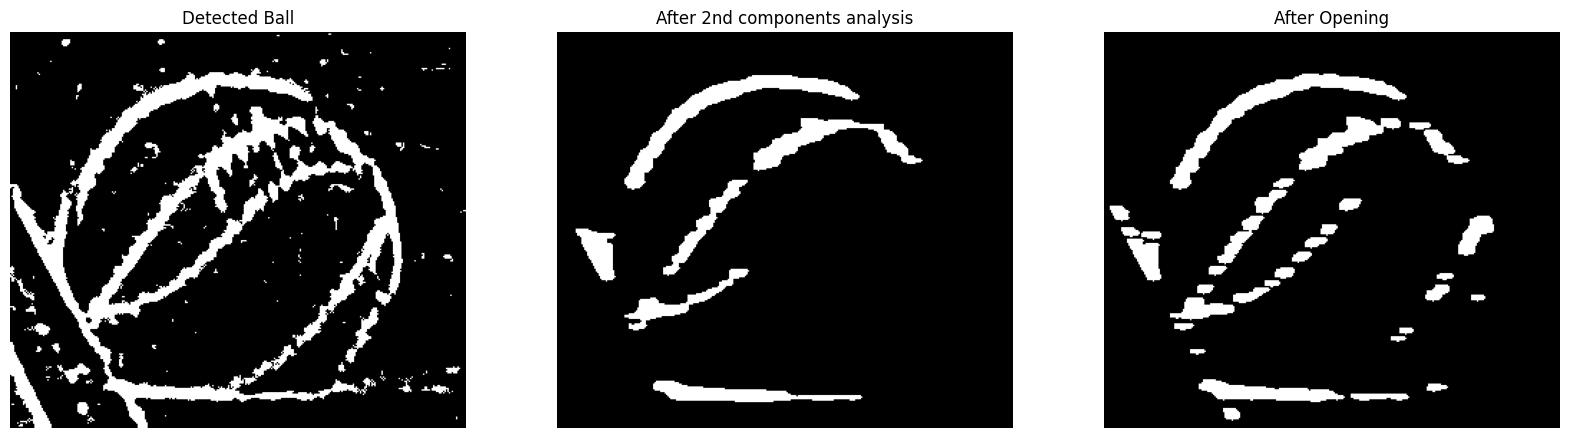

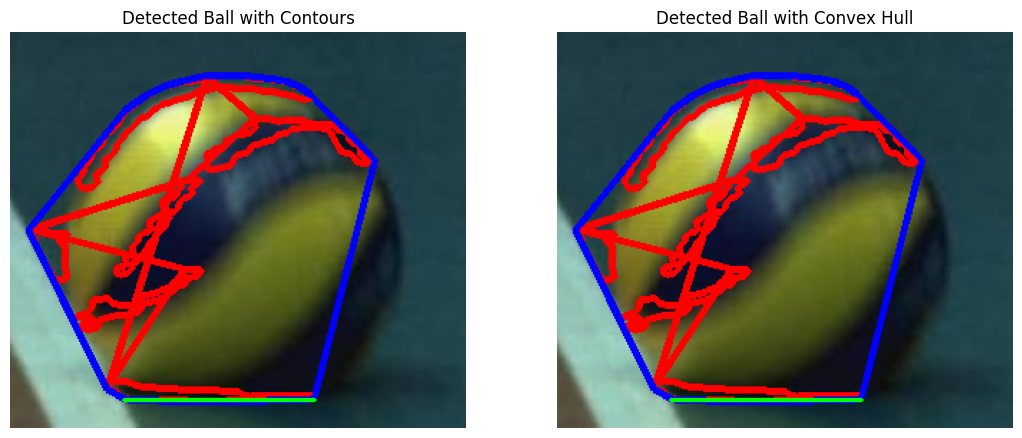

In [ ]:
def detect_ball(image_rgb, ball_mask):
    
    # Find contours that are circular in shape
    contours, _ = cv2.findContours(ball_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    image_rgb_contours = image_rgb.copy()
    image_rgb_contours = cv2.drawContours(image_rgb_contours, contours=contours, contourIdx=-1, color=(0,255,0), thickness=3)

    # Combine the two largest contours
    contours = sorted(contours, key=cv2.contourArea)
    largest_contour = max(contours, key=cv2.contourArea)
    second_largest_contour = contours[-2]
    combined_contour = np.concatenate((largest_contour, second_largest_contour))

    """# Draw a circle around the combined contour
    (x, y), radius = cv.minEnclosingCircle(combined_contour)
    center = (int(x), int(y))
    radius = int(radius)
    image_rgb = cv.circle(image_rgb, center, radius, color=(0,255,0), thickness=7)
    """
    
    # Get the bounding box of the contours and add a safe margin
    x, y, w, h = cv2.boundingRect(combined_contour)
    margin = 40

    H, W = image_rgb.shape[:2]
    x0 = max(x - margin, 0)
    y0 = max(y - margin, 0)
    x1 = min(x + w + margin, W - 1)
    y1 = min(y + h + margin, H - 1)

    # For display only: draw an outline bbox on a copy
    bounding_box_img = image_rgb.copy()
    cv2.rectangle(bounding_box_img, (x0, y0), (x1, y1), color=(0, 0, 0), thickness=2)

    # Crop the detected ball area from the original image
    detected_ball = image_rgb[y0:y1, x0:x1]

    ## ----- Futher prerocessing to isolate the ball ---- ##
    detected_ball_grey = cv2.cvtColor(detected_ball, cv2.COLOR_RGB2GRAY)
    detected_ball_blur = cv2.GaussianBlur(detected_ball_grey, (7,7), 0)

    ball_threshold = cv2.adaptiveThreshold(detected_ball_blur, maxValue=255, adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           thresholdType=cv2.THRESH_BINARY_INV, blockSize=21, C=2)
    # Apply components analysis to keep only the largest component
    total_labels, label_ids, stats, _ = cv2.connectedComponentsWithStats(ball_threshold, connectivity=4, stats=cv2.CV_32S)

    output = np.zeros_like(ball_threshold)

    # Keep only components that are larger than a certain area threshold and are not straight lines
    for i in range(1, total_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 800: 
            component_mask = (label_ids == i).astype("uint8") * 255
            output = cv2.bitwise_or(output, component_mask)

                
    # Open to smooth edges
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10,4))
    open_output = cv2.morphologyEx(output, cv2.MORPH_OPEN, kernel, iterations=1)
    close_output = cv2.morphologyEx(open_output, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Components analysis again to keep big components above a certain size
    total_labels, label_ids, stats, _ = cv2.connectedComponentsWithStats(close_output, connectivity=4, stats=cv2.CV_32S)
    final_output = np.zeros_like(close_output)
    for i in range(1, total_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 400: 
            final_output[label_ids == i] = 255

    ## -------------------------------------------------- ##

    # Detect contours on the final output
    ball_contours, _ = cv2.findContours(final_output, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # connect all the outlines to form a single contour
    if len(ball_contours) > 0:
        final_ball_contour = np.concatenate(ball_contours)
        #draw the final contour on the bounding box image
        detected_ball_drawn_contours = detected_ball.copy()
        detected_ball_drawn_contours = cv2.drawContours(detected_ball_drawn_contours, contours=[final_ball_contour], contourIdx=-1, color=(255,0,0), thickness=3)

        hull = cv2.convexHull(final_ball_contour)
        detected_ball_drawn_convex = detected_ball.copy()
        detected_ball_drawn_convex = cv2.drawContours(detected_ball_drawn_contours, contours=[hull], contourIdx=-1, color=(0,0,255), thickness=3)
        hull_pts = hull.reshape(-1, 2) 
        ys = hull_pts[:, 1]
        max_y = np.max(ys)

        tol = 5  # pixels tolerance around lowest point
        contact_pts = hull_pts[np.abs(ys - max_y) <= tol]

        if len(contact_pts) >= 2:
            x_min = int(np.min(contact_pts[:, 0]))
            x_max = int(np.max(contact_pts[:, 0]))
            contact_y = int(np.round(np.mean(contact_pts[:, 1])))

            # draw contact line on cropped ROI (green)
            cv2.line(
                detected_ball_drawn_convex,
                (x_min, contact_y),
                (x_max, contact_y),
                (0,255,0),
                2
            )

            # convert to full-image coordinates for decision pipeline
            p1_global = (x0 + x_min, y0 + contact_y)
            p2_global = (x0 + x_max, y0 + contact_y)
            contact_line_global = (p1_global, p2_global)


    # Displays the results
    plt.figure(figsize=(20,10))
    plt.subplot(1,3,1)
    plt.title('Contours on Original Image')
    plt.imshow(image_rgb_contours)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title('Final Detected Ball Contour')
    plt.imshow(bounding_box_img)
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.title('Cropped Detected Ball Area')
    plt.imshow(detected_ball_blur, cmap='gray')
    plt.axis('off')

    plt.figure(figsize=(20,10))
    plt.subplot(1,3,1)
    plt.title('Detected Ball')
    plt.imshow(ball_threshold, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title('After 2nd components analysis')
    plt.imshow(final_output, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.title('After Opening')
    plt.imshow(open_output, cmap='gray')
    plt.axis('off')
    
    plt.figure(figsize=(20,10))
    plt.subplot(1,3,1)
    plt.title('Detected Ball with Contours')
    plt.imshow(detected_ball_drawn_contours)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title('Detected Ball with Convex Hull')
    plt.imshow(detected_ball_drawn_convex)
    plt.axis('off')

    return image_rgb, contact_line_global

detected_image, contact_line = detect_ball(image_rgb, ball_mask)


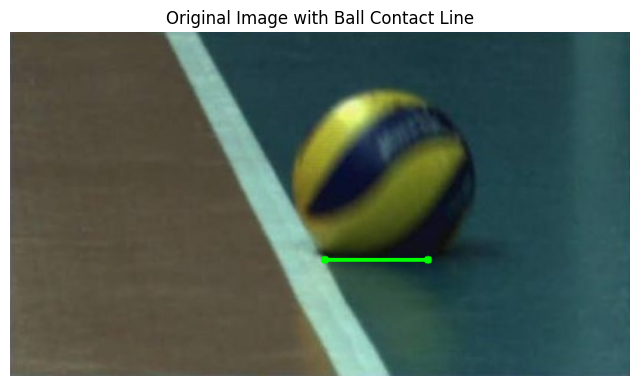

In [47]:
# Display the contact line on the original image
overlay = image_rgb.copy()

if contact_line is not None:
    (p1, p2) = contact_line # each is (x, y)
    
    # Draw the contact line in green (on the full image)
    cv2.line(overlay, p1, p2, (0, 255, 0), thickness=3)
    
    # mark the endpoints so you can see them clearly
    cv2.circle(overlay, p1, 5, (0, 255, 0), -1)
    cv2.circle(overlay, p2, 5, (0, 255, 0), -1)
plt.figure(figsize=(8,6))
plt.title("Original Image with Ball Contact Line")
plt.imshow(overlay)
plt.axis("off")
plt.show()

### Decision Making

This function will combine the line detection result image and point of contact line result image

In [48]:
def draw_courtLine_Contact(image_rgb, line_roi_mask, contact_line):
    """
    Returns an RGB image that is the original frame with:
      - courtline ROI filled in semi-transparent blue
      - ball contact line drawn in solid green
    """

    h, w = image_rgb.shape[:2]
    base = image_rgb.copy()

    # 1) Reconstruct courtline polygon from mask (largest contour)
    court_overlay = base.copy()
    if line_roi_mask is not None:
        mask = line_roi_mask.copy()
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            # take largest contour as courtline polygon
            court_cnt = max(contours, key=cv2.contourArea)

            # draw filled polygon on a transparent overlay
            poly_layer = np.zeros_like(base)
            cv2.fillPoly(poly_layer, [court_cnt], (0, 0, 255))   # blue court band (BGR)

            # alpha‑blend ONLY this polygon with the original
            alpha = 0.5
            # boolean mask of where polygon is
            poly_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(poly_mask, [court_cnt], 255)

            # blend per-pixel: courtline region = alpha*poly + (1-alpha)*base
            poly_mask_3 = np.dstack([poly_mask]*3)  # 3‑channel
            base = np.where(
                poly_mask_3 == 255,
                (alpha * poly_layer + (1 - alpha) * base).astype(base.dtype),
                base
            )

    # 2) Draw contact line in solid green
    if contact_line is not None:
        (p1, p2) = contact_line
        cv2.line(base, p1, p2, (0, 255, 0), 3)
        cv2.circle(base, p1, 5, (0, 255, 0), -1)
        cv2.circle(base, p2, 5, (0, 255, 0), -1)

    return base


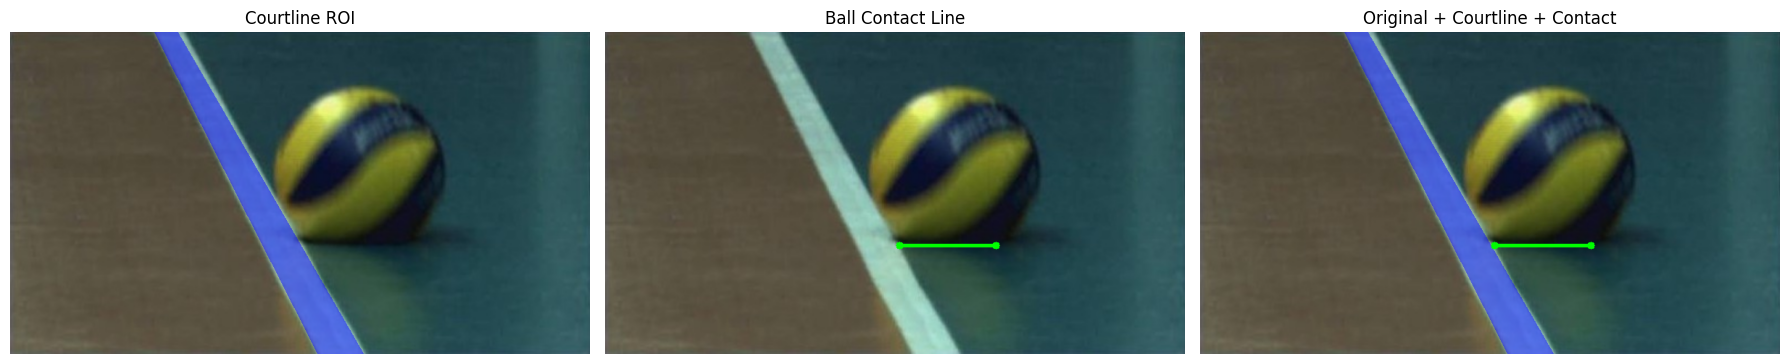

In [49]:
def combine_detections(image_rgb, vis_roi, line_roi_mask, contact_line):
    # 1) Overlay of ball contact line only
    overlay_contact = image_rgb.copy()
    if contact_line is not None:
        (p1, p2) = contact_line
        cv2.line(overlay_contact, p1, p2, (0, 255, 0), 3)
        cv2.circle(overlay_contact, p1, 5, (0, 255, 0), -1)
        cv2.circle(overlay_contact, p2, 5, (0, 255, 0), -1)

    # 2) Combined back onto original (courtline + contact)
    combined_on_original = draw_courtLine_Contact(image_rgb, line_roi_mask, contact_line)

    # 3) Show: courtline ROI view, contact line view, final original-with-both
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(vis_roi)
    axes[0].set_title("Courtline ROI")
    axes[0].axis("off")

    axes[1].imshow(overlay_contact)
    axes[1].set_title("Ball Contact Line")
    axes[1].axis("off")

    axes[2].imshow(combined_on_original)
    axes[2].set_title("Original + Courtline + Contact")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# CELL 9 call:
combine_detections(image_rgb, vis_roi, line_roi_mask, contact_line)


This cell computes whether the ball is “IN” or “OUT” based on how much of the contact line overlaps the courtline ROI mask, then draws both the courtline and contact line on the original image and displays it with a title summarising the decision and overlap ratio.

Decision: OUT (overlap ratio = 0.00)


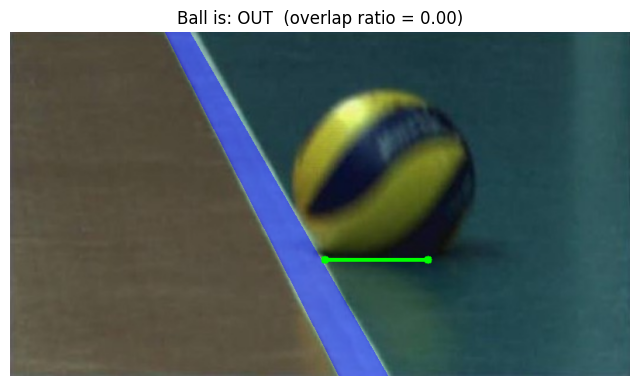

In [50]:
# Decision if the Ball is "IN" or "OUT" based on overlap ratio
def decide_in_or_out(line_roi_mask, contact_line, thickness=3, overlap_ratio_thresh=0.3):
    if contact_line is None or line_roi_mask is None:
        return "UNKNOWN", 0.0

    (p1, p2) = contact_line
    seg_mask = np.zeros_like(line_roi_mask, dtype=np.uint8)
    cv2.line(seg_mask, p1, p2, 255, thickness=thickness)

    seg_pixels = (seg_mask == 255)
    num_seg_pixels = np.count_nonzero(seg_pixels)
    if num_seg_pixels == 0:
        return "UNKNOWN", 0.0

    overlap_pixels = np.logical_and(seg_pixels, line_roi_mask == 255)
    num_overlap = np.count_nonzero(overlap_pixels)

    overlap_ratio = num_overlap / float(num_seg_pixels)
    decision = "IN" if overlap_ratio >= overlap_ratio_thresh else "OUT"
    return decision, overlap_ratio


# ---- run decision + show (uses existing draw_courtline_and_contact_on_original) ----
decision, overlap = decide_in_or_out(line_roi_mask, contact_line)
print(f"Decision: {decision} (overlap ratio = {overlap:.2f})")

final_image = draw_courtLine_Contact(image_rgb, line_roi_mask, contact_line)

plt.figure(figsize=(8, 6))
plt.imshow(final_image)
plt.title(f"Ball is: {decision}  (overlap ratio = {overlap:.2f})")
plt.axis("off")
plt.show()
